In [1]:
%matplotlib inline
import torch
from torch.distributions import multinomial
from d2l import torch as d2l



In [15]:
a = torch.ones([6])
fair_probs = a / 6
a, fair_probs , multinomial.Multinomial(1, fair_probs).sample()


(tensor([1., 1., 1., 1., 1., 1.]),
 tensor([0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667]),
 tensor([0., 0., 0., 0., 0., 1.]))

In [21]:
multinomial.Multinomial(10, fair_probs).sample()



tensor([1., 1., 2., 2., 2., 2.])

In [25]:
n = 10000
counts = multinomial.Multinomial(n, fair_probs).sample()
counts / n

tensor([0.1686, 0.1698, 0.1721, 0.1616, 0.1657, 0.1622])

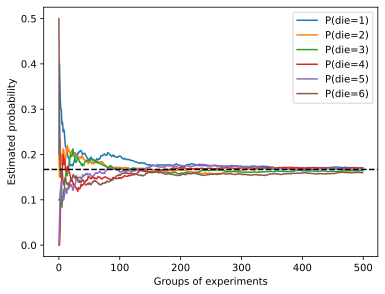

In [26]:
counts = multinomial.Multinomial(10, fair_probs).sample((500,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)

d2l.set_figsize((6, 4.5))
for i in range(6):
    d2l.plt.plot(estimates[:, i].numpy(),
                 label=("P(die=" + str(i + 1) + ")"))
d2l.plt.axhline(y=0.167, color='black', linestyle='dashed')
d2l.plt.gca().set_xlabel('Groups of experiments')
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend();
